In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

DENOISED_DIR = PROJECT_ROOT / "data" / "processed" / "denoised"

In [2]:
import sys

sys.path.append(str(PROJECT_ROOT / "src"))

from segmentation.mean_shift import MeanShiftSegmenter

In [3]:
images = sorted(DENOISED_DIR.glob("*.png"))

print(f"Total images: {len(images)}")

image_path = images[0]

print(image_path)

Total images: 30
..\data\processed\denoised\frame_000001.png


In [4]:
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

segmenter = MeanShiftSegmenter(
    spatial_radius=20,
    color_radius=30,
    quantization=16
)

segmented = segmenter.segment(image)

labels = segmenter.segmentation_map(segmented)

colored = segmenter.colorize(labels)

regions = segmenter.count_regions(labels)

print("Number of regions:", regions)

Number of regions: 258


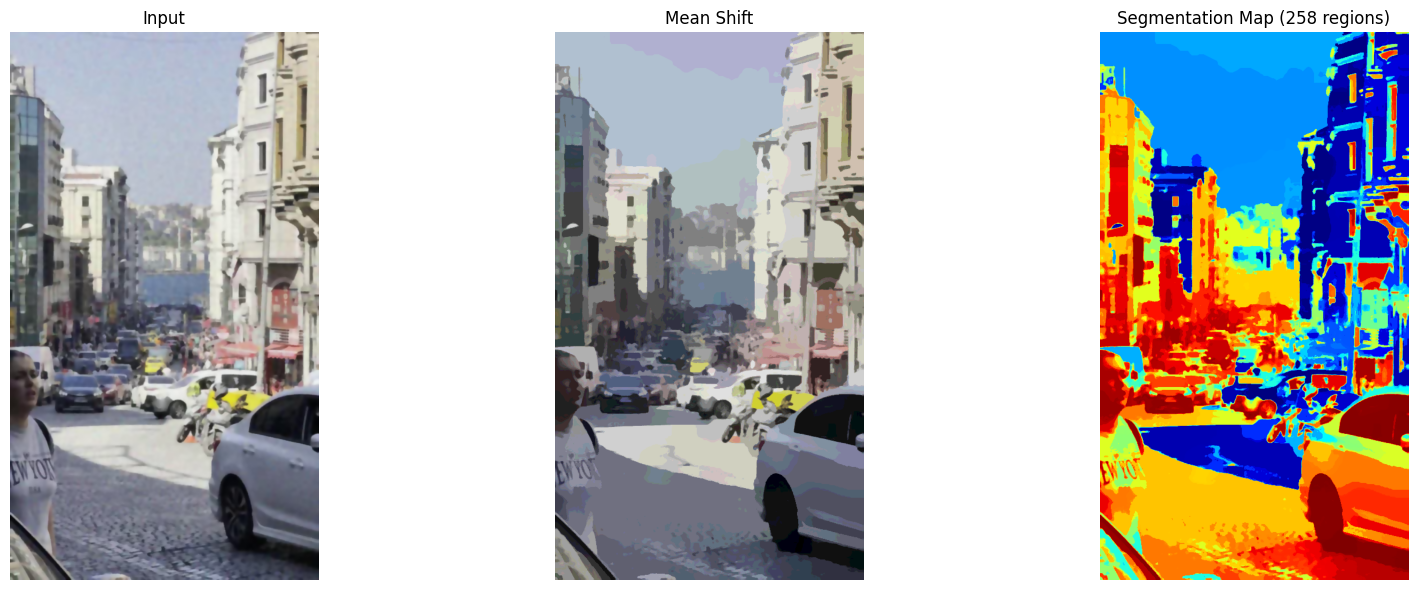

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image)
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(segmented)
ax[1].set_title("Mean Shift")
ax[1].axis("off")

ax[2].imshow(colored)
ax[2].set_title(f"Segmentation Map ({regions} regions)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

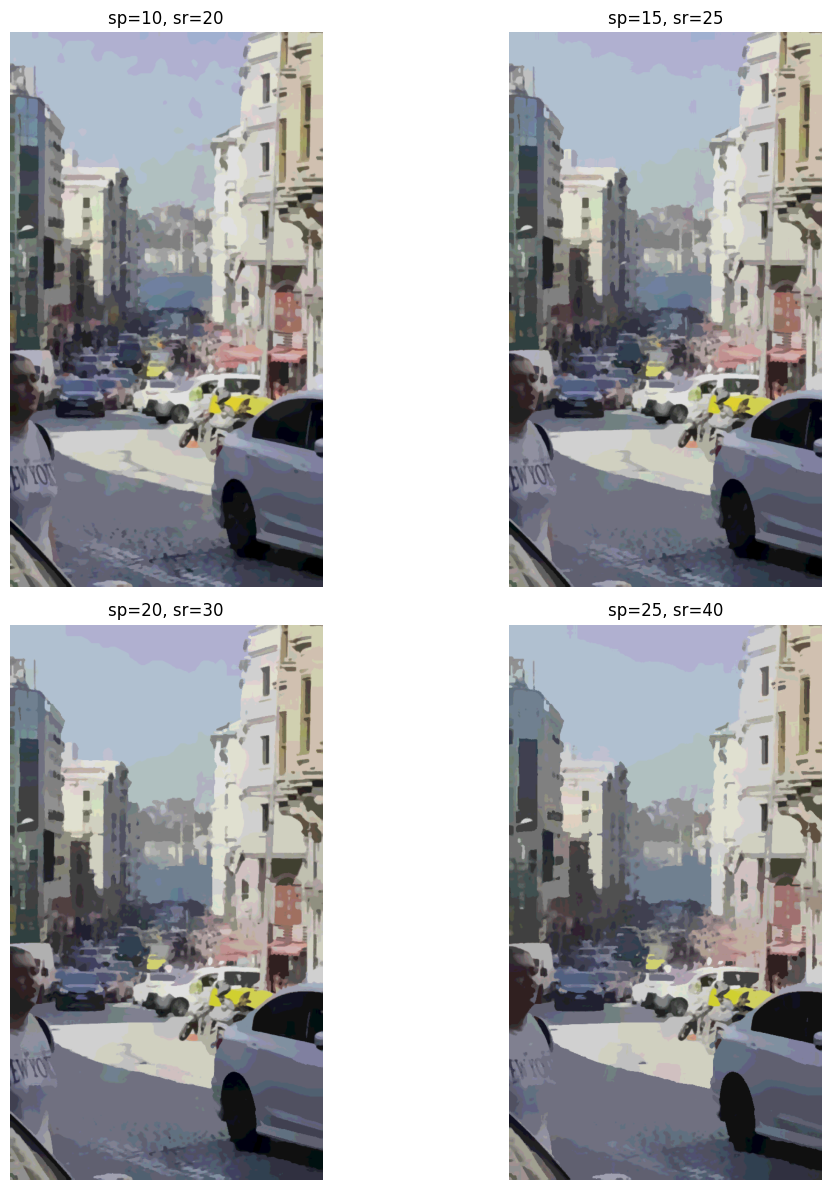

In [6]:
settings = [
    (10, 20),
    (15, 25),
    (20, 30),
    (25, 40),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (sp, sr) in zip(axes.ravel(), settings):

    segmenter = MeanShiftSegmenter(
        spatial_radius=sp,
        color_radius=sr,
        quantization=16
    )

    result = segmenter.segment(image)

    ax.imshow(result)
    ax.set_title(f"sp={sp}, sr={sr}")
    ax.axis("off")

plt.tight_layout()
plt.show()